<a href="https://colab.research.google.com/github/armnkumar321-spec/pythonclasses/blob/main/last.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Finance Data Mini project

##import library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_excel('financial_loan.xlsx')
display(df.head)

<bound method NDFrame.head of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat Technology Inc     C           RENT 2021-01-05   
3                  barnes distribution     B       MORTGAGE 2021-02-25   
4                        J&J Steel Inc     A       MORTGAGE 2021-01-01   
...                                ...   ...            ...        ...   
38571         Joseph M Sanzari Company     C       MORTGAGE 2021-07-11   
38572                        Swat Fame     C           RENT 2021-10-11   
38573  Anaheim Regional Medical Center     D           RENT 2021-09-11   
38574               Brooklyn Radiology     D           RENT 2021-10-11   
38575                    Allen Edmonds     F           RENT 2021-07-11   

      last_credit_pull_date last_payment_date  ... sub_grade        term  \
0                2021-09-13        2021-04-13  ...        C4   60 months   
1                2021-12-14        2021-01-15  ...        E1   36 months   
2                2021-12-12        2021-01-09  ...        C5   36 months   
3                2021-12-12        2021-03-12  ...        B2   60 months   
4                2021-12-14        2021-01-15  ...        A1   36 months   
...                     ...               ...  ...       ...         ...   
38571            2021-05-16        2021-05-16  ...        C1   60 months   
38572            2021-04-16        2021-05-16  ...        C1   60 months   
38573            2021-05-16        2021-05-16  ...        D5   60 months   
38574            2021-05-16        2021-05-16  ...        D5   60 months   
38575            2021-05-16        2021-05-16  ...        F3   60 months   

       verification_status annual_income     dti installment int_rate  \
0          Source Verified       30000.0  0.0100       59.83   0.1527   
1          Source Verified       48000.0  0.0535      109.43   0.1864   
2             Not Verified       50000.0  0.2088      421.65   0.1596   
3          Source Verified       42000.0  0.0540       97.06   0.1065   
4                 Verified       83000.0  0.0231      106.53   0.0603   
...                    ...           ...     ...         ...      ...   
38571             Verified      100000.0  0.1986      551.64   0.1299   
38572             Verified       50000.0  0.0458      579.72   0.1349   
38573             Verified       65000.0  0.1734      627.93   0.1749   
38574             Verified      368000.0  0.0009      612.72   0.1825   
38575             Verified       80000.0  0.0600      486.86   0.2099   

       loan_amount  total_acc  total_payment  
0             2500          4           1009  
1             3000          4           3939  
2            12000         11           3522  
3             4500          9           4911  
4             3500         28           3835  
...            ...        ...            ...  
38571        24250         33          31946  
38572        25200         18          31870  
38573        25000         20          35721  
38574        24000          9          33677  
38575        18000          7          27679  

[3857

### Initial Data Analysis

#Meta deta


In [ ]:
print(df.shape)

(38576, 24)


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


##date time agr format mai ni hai to cahnge kre date ko fomat main aur find kre null value


##anylise data

In [ ]:
total_loans = df.shape[0]
print(f"Total number of loan statements: {total_loans}")

Total number of loan statements: 38576


In [ ]:
unique_loan_ids = df['id'].nunique()
print(unique_loan_ids)



38576


In [ ]:
curr_date = pd.Timestamp.today()
curr_day = curr_date.day
curr_month = curr_date.month

today_applications = df[(df['issue_date'].dt.month == curr_month) & (df['issue_date'].dt.day <= curr_day)]

num_app_today = today_applications['id'].nunique()
print( num_app_today)

total_loan_amount_today = today_applications['loan_amount'].sum()
print( total_loan_amount_today)

3184
34161475


In [ ]:
total_loan_amount_million = total_loan_amount_today / 1_000_000
total_loan_amount_billion = total_loan_amount_today / 1_000_000_000

print(f"Total loan amount up to today in the current month (Millions): ${total_loan_amount_million:.2f} M")
print(f"Total loan amount up to today in the current month (Billions): ${total_loan_amount_billion:.2f} B")

Total loan amount up to today in the current month (Millions): $34.16 M
Total loan amount up to today in the current month (Billions): $0.03 B


## Loan Status Analysis

### Loan Status Classification

### Grouping by Loan Status

In [ ]:
loan_status_grouped = df.groupby('loan_status').agg({
    'id':'count',
    'dti':'mean',
    'loan_amount':'sum',
    'int_rate':'mean'
})
loan_status_grouped.rename(columns={'id':'loan_count'},inplace=True)


display(loan_status_grouped)

good_lone_application=loan_status_grouped.loc[['Fully Paid' ,'Current'], 'loan_count']
print(good_lone_application)
good_lone_application_sum=good_lone_application.sum()
print(good_lone_application_sum)

NameError: name 'df' is not defined

In [ ]:
good_lone_application=loan_status_grouped.loc[['Fully Paid' ,'Current'], 'loan_count']
print(good_lone_application)
good_lone_application_sum=good_lone_application.sum()
print(good_lone_application_sum)


loan_status
Fully Paid    32145
Current        1098
Name: loan_count, dtype: int64
33243


In [ ]:
good_loan_funded_amount = loan_status_grouped.loc[['Fully Paid', 'Current'], 'loan_amount'].sum()
print(f" ${good_loan_funded_amount:,.2f}")

 $370,224,850.00


### Monthly Loan Amount Trend

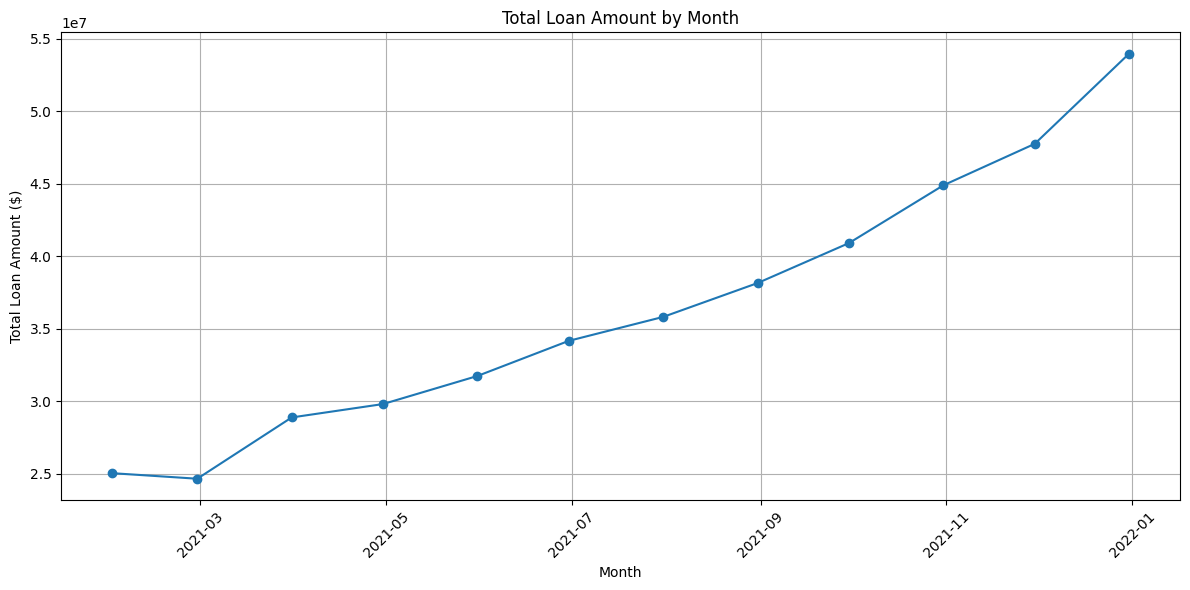

In [ ]:

monthly_loan_amount = df.set_index('issue_date')['loan_amount'].resample('ME').sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(monthly_loan_amount['issue_date'], monthly_loan_amount['loan_amount'], marker='o')



plt.title('Total Loan Amount by Month')
plt.xlabel('Month')
plt.ylabel('Total Loan Amount ($)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
df['month']=df['issue_date'].dt.month
new_df=df.groupby('month').agg({
    'loan_amount':'sum'

})
plt.plot(new_df['month'],new_df['loan_amount'])
plt.show()

KeyError: 'month'

recievd ammount graph